# Classical ML baselines on v2 data

Logistic Regression, SVM (RBF), and XGBoost on the same v2 TFRecords used by the Astronet-Triage v2 / Yu comparison. Features are just the concatenation of `global_view` (201) and `local_view` (61) time series (262-dim vector); target is `disp_E > 0`.

The three classifiers are trained on `data/tfrecords/train/*` and evaluated on `data/tfrecords/test/*`. Results are compared via PR curves, confusion matrices at `p >= 0.5`, and a summary table.

**Dependencies:** `xgboost` must be installed in this kernel — `pip install xgboost` if missing.

In [1]:
import glob
import numpy as np
import pandas as pd
import tensorflow as tf

TRAIN_GLOB = 'data/tfrecords/train/*'
TEST_GLOB = 'data/tfrecords/test/*'

GV_LEN = 201
LV_LEN = 61

## 1. Load TFRecords into flat arrays

In [2]:
def load_split(pattern):
    astro_ids, gv, lv, disp_e = [], [], [], []
    for f in sorted(glob.glob(pattern)):
        for rec in tf.data.TFRecordDataset(f):
            ex = tf.train.Example.FromString(rec.numpy())
            feat = ex.features.feature
            astro_ids.append(feat['astro_id'].int64_list.value[0])
            gv.append(list(feat['global_view'].float_list.value))
            lv.append(list(feat['local_view'].float_list.value))
            disp_e.append(feat['disp_E'].int64_list.value[0])
    gv_arr = np.asarray(gv, dtype=np.float32)
    lv_arr = np.asarray(lv, dtype=np.float32)
    X = np.concatenate([gv_arr, lv_arr], axis=1)
    y = (np.asarray(disp_e, dtype=np.int64) > 0).astype(int)
    return np.asarray(astro_ids), X, y


astro_train, X_train, y_train = load_split(TRAIN_GLOB)
astro_test, X_test, y_test = load_split(TEST_GLOB)
print(f'train: X={X_train.shape}, pos rate={y_train.mean():.3f}')
print(f'test : X={X_test.shape}, pos rate={y_test.mean():.3f}')

train: X=(19918, 262), pos rate=0.105
test : X=(2516, 262), pos rate=0.099


## 2. Logistic Regression

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', n_jobs=-1)),
])
logreg.fit(X_train, y_train)
p_lr = logreg.predict_proba(X_test)[:, 1]
print('LogReg done')

c:\Users\danie\anaconda3\envs\astronet\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogReg done


## 3. SVM (RBF)
RBF-kernel SVM with probability output. This is the slowest of the three — expect multiple minutes on a few-thousand-row train set. Swap to `LinearSVC` with `CalibratedClassifierCV` if needed.

In [4]:
from sklearn.svm import SVC

svm = Pipeline([
    ('scale', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0)),
])
svm.fit(X_train, y_train)
p_svm = svm.predict_proba(X_test)[:, 1]
print('SVM done')

SVM done


## 4. XGBoost

In [6]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [7]:
import xgboost as xgb

xgbc = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=0,
)
xgbc.fit(X_train, y_train)
p_xgb = xgbc.predict_proba(X_test)[:, 1]
print('XGBoost done')

XGBoost done


## 5. PR curves

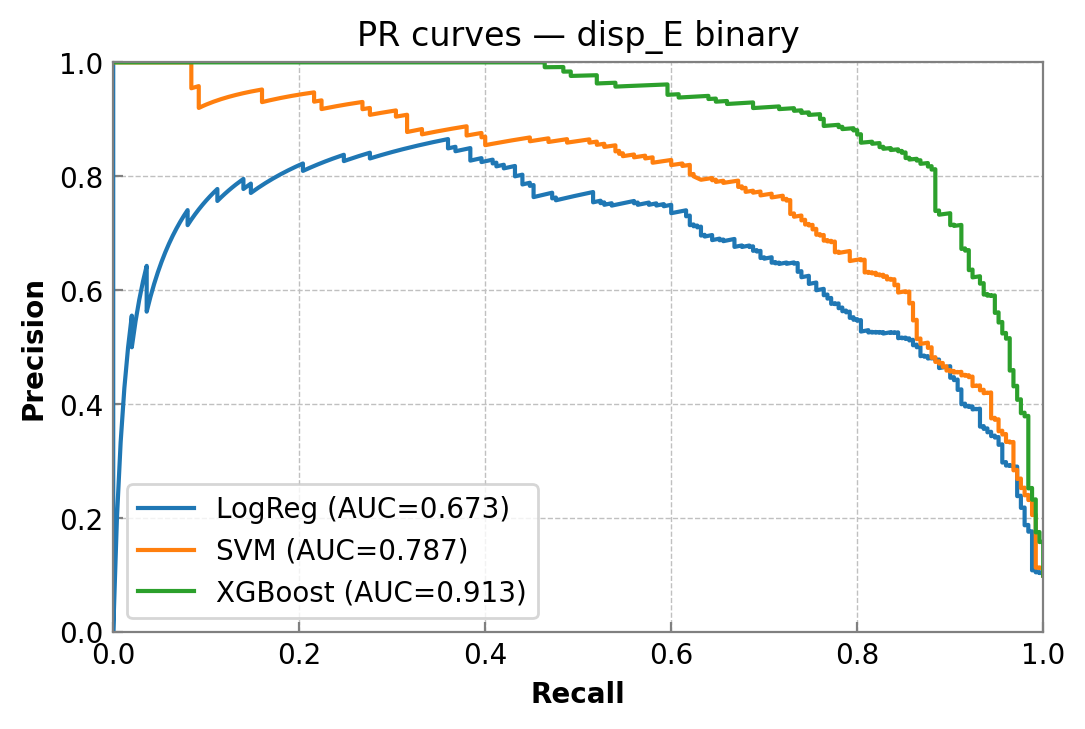

In [8]:
from sklearn import metrics
from matplotlib import pyplot as plt

MODELS = [('LogReg', p_lr), ('SVM', p_svm), ('XGBoost', p_xgb)]

fig, ax = plt.subplots(figsize=(6, 3.7), dpi=200)
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_color('#808080')
ax.tick_params(direction='in', color='#808080')
ax.grid(color='#c0c0c0', linestyle='--', linewidth=0.5)

for name, p in MODELS:
    ps, rs, _ = metrics.precision_recall_curve(y_test, p)
    auc = metrics.auc(rs, ps)
    ax.plot(rs, ps, label=f'{name} (AUC={auc:.3f})')

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='lower left')
ax.set_title('PR curves — disp_E binary')
plt.show()

## 6. Confusion matrices at p ≥ 0.5

=== LogReg  th=0.5 ===
                 pred not disp_E  pred disp_E
true not disp_E             2221           45
true disp_E                  116          134
TP=134  FP=45  FN=116  TN=2221
Precision: 0.7486   Recall: 0.5360


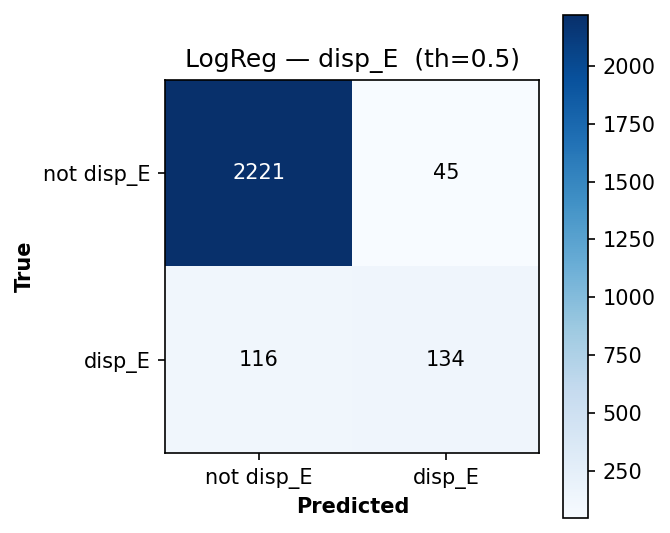

=== SVM  th=0.5 ===
                 pred not disp_E  pred disp_E
true not disp_E             2225           41
true disp_E                   92          158
TP=158  FP=41  FN=92  TN=2225
Precision: 0.7940   Recall: 0.6320


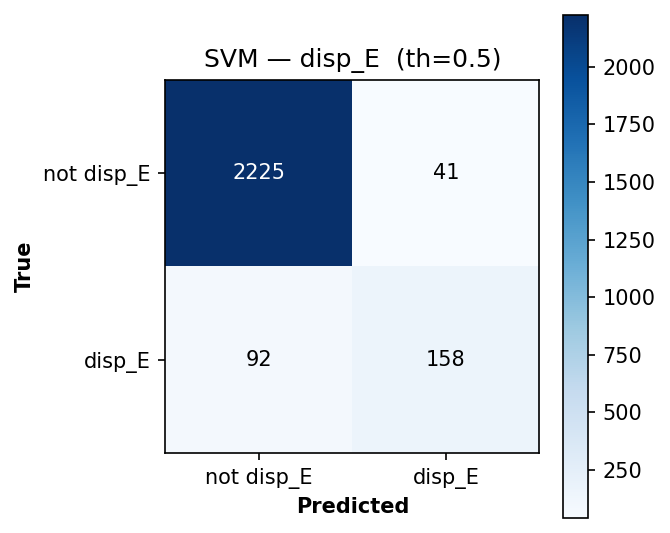

=== XGBoost  th=0.5 ===
                 pred not disp_E  pred disp_E
true not disp_E             2234           32
true disp_E                   49          201
TP=201  FP=32  FN=49  TN=2234
Precision: 0.8627   Recall: 0.8040


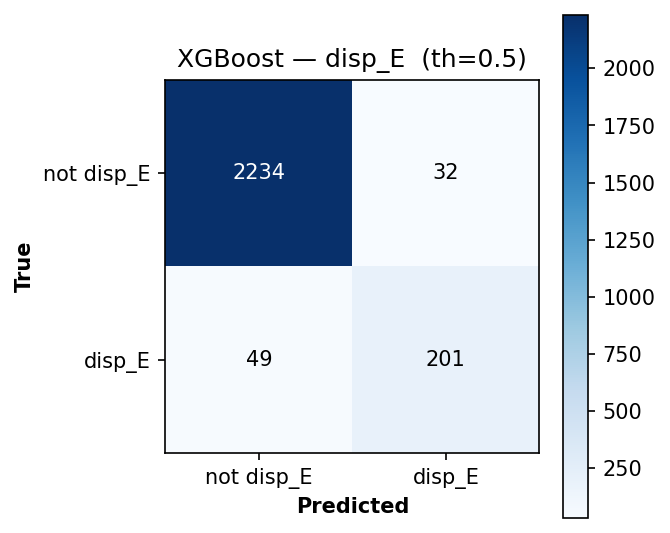

In [9]:
from sklearn.metrics import confusion_matrix

bin_labels = ['not disp_E', 'disp_E']


def show_cm(name, p, th=0.5):
    y_pred_bin = (p >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    cm_df = pd.DataFrame(cm,
                         index=[f'true {l}' for l in bin_labels],
                         columns=[f'pred {l}' for l in bin_labels])
    print(f'=== {name}  th={th} ===')
    print(cm_df)
    print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    print(f'Precision: {prec:.4f}   Recall: {rec:.4f}')

    fig, ax = plt.subplots(figsize=(4.5, 4), dpi=150)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(bin_labels); ax.set_yticklabels(bin_labels)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True', fontweight='bold')
    ax.set_title(f'{name} — disp_E  (th={th})')
    mid = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > mid else 'black')
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


for name, p in MODELS:
    show_cm(name, p)

## 7. Summary table
PR-AUC, precision/recall at `p ≥ 0.5`, and precision at 100%-recall threshold.

In [10]:
def full_recall_precision(y_true, p):
    ps, rs, ths = metrics.precision_recall_curve(y_true, p)
    # sklearn appends (0, 1) at the end; walk from high-recall side
    idx = np.where(rs == 1.0)[0]
    if len(idx) == 0:
        return 0.0, None
    i = idx.max()
    th = ths[i - 1] if i > 0 and i - 1 < len(ths) else None
    return float(ps[i]), float(th) if th is not None else None


rows = []
for name, p in MODELS:
    ps, rs, _ = metrics.precision_recall_curve(y_test, p)
    auc = metrics.auc(rs, ps)
    y_pred = (p >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    p100, th100 = full_recall_precision(y_test, p)
    rows.append({
        'model': name,
        'PR_AUC': auc,
        'P@0.5': prec,
        'R@0.5': rec,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'P@100R': p100,
        'threshold@100R': th100,
    })

pd.DataFrame(rows).set_index('model')

,PR_AUC,P@0.5,R@0.5,TP,FP,FN,TN,P@100R,threshold@100R
model,,,,,,,,,
LogReg,0.673494,0.748603,0.536,134,45,116,2221,0.104123,0.000002
SVM,0.786709,0.793970,0.632,158,41,92,2225,0.113071,0.000002
XGBoost,0.913303,0.862661,0.804,201,32,49,2234,0.158629,0.000014
